# Chapter 4 — Discrete Random Variables

Random variables that count things, their expected values, and the named distributions.

| Section | What it covers |
|---|---|
| 4.1 | Expectation |
| 4.2 | Variance of a random variable |
| 4.3 | The named discrete distributions |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Discrete Random Variables](https://khh-aka-lucifer.github.io/statLab/chapters/discrete-random-variables/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## A random variable you can count

A **random variable** attaches a number to a random outcome. A **discrete** one takes values you can
list, usually because it counts something.

Pick a Titanic passenger at random and count their family aboard, adding siblings and spouse
(`sibsp`) to parents and children (`parch`). Call that $X$. It is a genuine random variable with a
genuine distribution, and we can read that distribution straight off the passenger list.

In [2]:
titanic = pd.read_csv(DATA / "titanic.csv")
family = titanic["sibsp"] + titanic["parch"]

counts = family.value_counts().sort_index()
pmf = counts / counts.sum()

x = pmf.index.to_numpy()          # the values X can take
p = pmf.to_numpy()                # the probability of each one

table = pd.DataFrame({"x": x, "count": counts.to_numpy(), "P(X = x)": p.round(4)})
table

,x,count,P(X = x)
0,0,537,0.6027
1,1,161,0.1807
2,2,102,0.1145
3,3,29,0.0325
4,4,15,0.0168
5,5,22,0.0247
6,6,12,0.0135
7,7,6,0.0067
8,10,7,0.0079


That `P(X = x)` column is the **probability mass function**, or PMF. Two rules make it a PMF rather
than just a list of numbers: every entry is between 0 and 1, and they add to exactly 1.

In [3]:
print(f"all between 0 and 1: {bool(((p >= 0) & (p <= 1)).all())}")
print(f"they sum to:         {p.sum():.10f}")

all between 0 and 1: True
they sum to:         1.0000000000


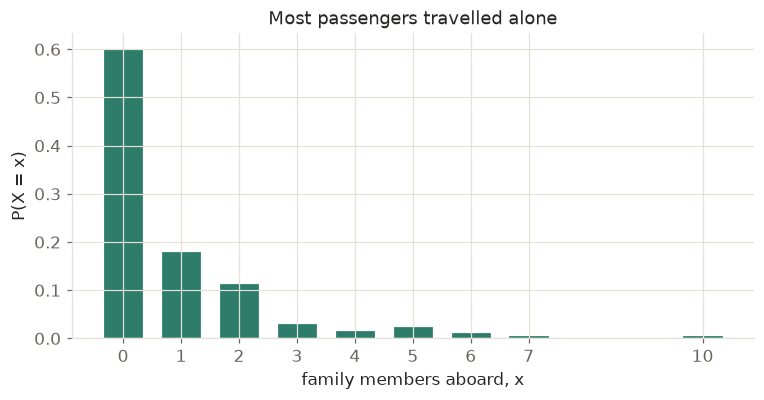

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x, p, color=C["accent"], edgecolor="white", linewidth=0.8, width=0.7)
ax.set_xlabel("family members aboard, x"); ax.set_ylabel("P(X = x)")
ax.set_title("Most passengers travelled alone")
ax.set_xticks(x)
plt.show()

## 4.1 Expectation

The **expected value** is the probability-weighted average of the values,

$$E[X] = \sum x \, P(X = x)$$

It is where the PMF balances. Note straight away that it need not be a value $X$ can actually take.

In [5]:
expected = (x * p).sum()

print(f"E[X] from the PMF   = {expected:.4f}")
print(f"mean of the column  = {family.mean():.4f}")
print()
print("Same number, two routes. The PMF route is the definition, the column route is the shortcut.")

E[X] from the PMF   = 0.9046
mean of the column  = 0.9046

Same number, two routes. The PMF route is the definition, the column route is the shortcut.


0.905 family members. No passenger had 0.905 relatives aboard. The expected value is a balance
point, not a prediction, and that is the single most common misreading of it.

You can also watch it emerge. Average a growing number of random passengers and the running mean
walks toward $E[X]$, which is the law of large numbers doing its work.

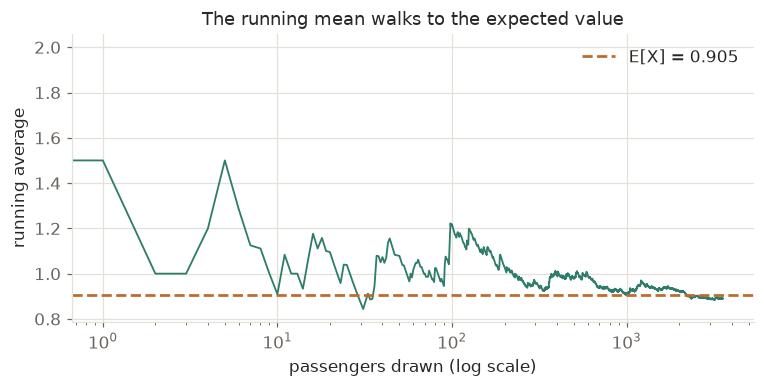

In [6]:
draws = family.sample(len(family) * 4, replace=True, random_state=0).to_numpy()
running = np.cumsum(draws) / np.arange(1, len(draws) + 1)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(running, color=C["accent"], lw=1.2)
ax.axhline(expected, color=C["warn"], ls="--", lw=1.8, label=f"E[X] = {expected:.3f}")
ax.set_xscale("log")

ax.set_xlabel("passengers drawn (log scale)"); ax.set_ylabel("running average")
ax.set_title("The running mean walks to the expected value")
ax.legend()
plt.show()

In [ ]:
# Your turn.
# Build the PMF of `pclass` (which is 1, 2 or 3) and compute E[pclass] from it.
# Then check it against titanic["pclass"].mean().
# Does the expected value mean anything useful here? Answer in a comment.

...

## 4.2 Variance of a random variable

Expectation says where. **Variance** says how far from there, weighting each squared distance by how
likely it is,

$$\mathrm{Var}(X) = \sum (x - \mu)^2 P(X = x)$$

and the standard deviation is its square root, back in the original units.

In [7]:
mu = expected
variance = (((x - mu) ** 2) * p).sum()

print(f"Var(X) = {variance:.4f}")
print(f"SD(X)  = {np.sqrt(variance):.4f}")
print()
print(f"pandas var(ddof=0) = {family.var(ddof=0):.4f}   <- matches, because we have the whole population")

Var(X) = 2.6003
SD(X)  = 1.6126

pandas var(ddof=0) = 2.6003   <- matches, because we have the whole population


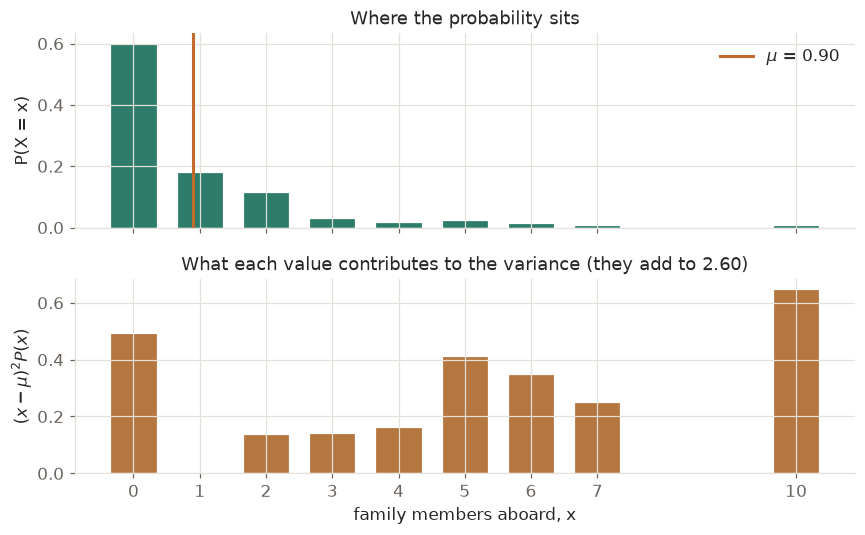

In [8]:
contribution = ((x - mu) ** 2) * p

fig, (top, bottom) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

top.bar(x, p, color=C["accent"], edgecolor="white", linewidth=0.8, width=0.7)
top.axvline(mu, color=C["warn"], lw=2, label=rf"$\mu$ = {mu:.2f}")
top.set_ylabel("P(X = x)"); top.legend(); top.set_title("Where the probability sits")

bottom.bar(x, contribution, color=C["cat2"], edgecolor="white", linewidth=0.8, width=0.7)
bottom.set_ylabel(r"$(x-\mu)^2 P(x)$"); bottom.set_xlabel("family members aboard, x")
bottom.set_title(f"What each value contributes to the variance (they add to {variance:.2f})")
bottom.set_xticks(x)

plt.tight_layout()
plt.show()

The second chart is the useful one. The families of 10 are only 0.8 % of passengers, yet because
they sit so far from the mean their squared distance is enormous and they contribute more variance
than the 60 % of passengers travelling alone. Squaring means far points dominate, which is exactly
why a single outlier can wreck a standard deviation.

In [ ]:
# Your turn.
# Compute Var(fare) two ways: from a PMF you build yourself, and with pandas .var(ddof=0).
# fare is nearly continuous, so build the PMF with pd.cut into 10 bins first and use bin midpoints.
# Your two answers will be close but not identical. Why?

...

## 4.3 The named discrete distributions

Some counting situations come up so often that their distributions have names and formulas. Three
matter here, and `scipy.stats` knows all of them.

The **binomial** counts successes in $n$ independent trials that share the same chance $p$. The
**geometric** counts trials until the first success. The **Poisson** counts rare events at an
average rate $\lambda$.

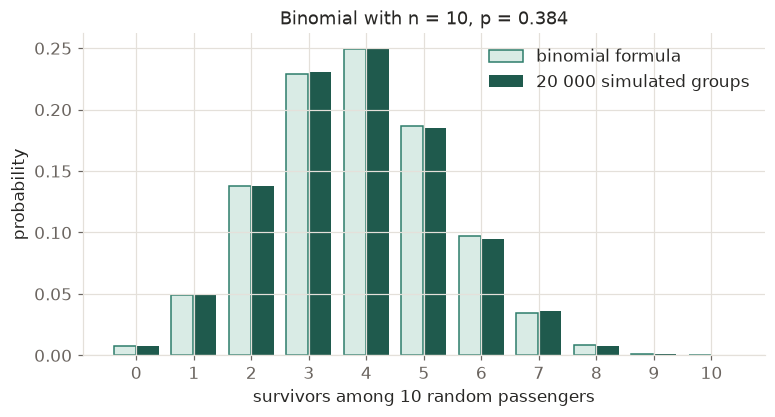

E[X] = n p       = 3.838   simulated 3.831
Var  = n p (1-p) = 2.365   simulated 2.365


In [9]:
p_survive = titanic["survived"].mean()
n = 10

k = np.arange(0, n + 1)
theory = stats.binom.pmf(k, n, p_survive)

# simulate it: draw 10 passengers at random, 20000 times, and count survivors
sim = rng.binomial(n, p_survive, 20000)
observed = np.bincount(sim, minlength=n + 1) / len(sim)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(k - 0.2, theory, width=0.38, color=C["accent_soft"], edgecolor=C["accent"], label="binomial formula")
ax.bar(k + 0.2, observed, width=0.38, color=C["accent_strong"], label="20 000 simulated groups")

ax.set_xlabel("survivors among 10 random passengers"); ax.set_ylabel("probability")
ax.set_title(f"Binomial with n = {n}, p = {p_survive:.3f}")
ax.set_xticks(k); ax.legend()
plt.show()

print(f"E[X] = n p       = {n * p_survive:.3f}   simulated {sim.mean():.3f}")
print(f"Var  = n p (1-p) = {n * p_survive * (1 - p_survive):.3f}   simulated {sim.var():.3f}")

### When the named distribution does not fit

Textbooks show you distributions that fit. Real data often refuses, and noticing that is a skill.

The Poisson has one parameter, $\lambda$, and it makes a strong promise: the mean and the variance
are both $\lambda$. Count the heavy-rain days in each of the 48 months of Seattle data and check.

In [10]:
weather = pd.read_csv(DATA / "seattle-weather.csv", parse_dates=["date"])
weather["month"] = weather["date"].dt.to_period("M")

heavy = (weather.assign(big=weather["precipitation"] > 10)
         .groupby("month")["big"].sum())

print(f"months observed : {len(heavy)}")
print(f"mean per month  : {heavy.mean():.3f}")
print(f"variance        : {heavy.var(ddof=0):.3f}")
print()
print("A Poisson would need those last two to be about equal. They are not, by a factor of two.")

months observed : 48
mean per month  : 3.000
variance        : 6.792

A Poisson would need those last two to be about equal. They are not, by a factor of two.


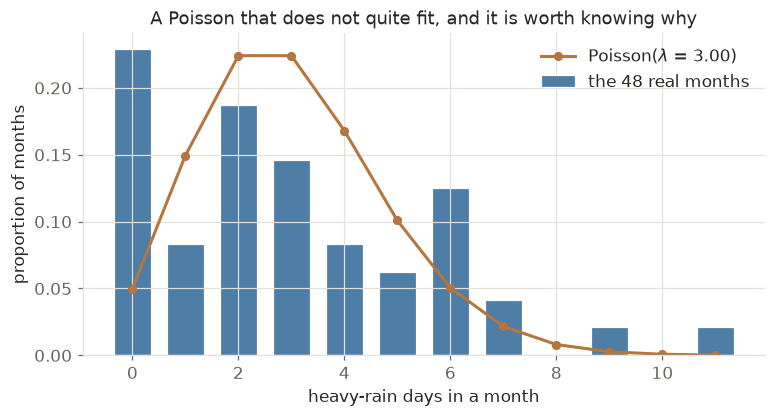

In [11]:
lam = heavy.mean()
k = np.arange(0, heavy.max() + 1)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(k, np.bincount(heavy.to_numpy(), minlength=len(k))[:len(k)] / len(heavy),
       width=0.7, color=C["cat3"], edgecolor="white", linewidth=0.8, label="the 48 real months")
ax.plot(k, stats.poisson.pmf(k, lam), "o-", color=C["cat2"], lw=2, ms=5,
        label=rf"Poisson($\lambda$ = {lam:.2f})")

ax.set_xlabel("heavy-rain days in a month"); ax.set_ylabel("proportion of months")
ax.set_title("A Poisson that does not quite fit, and it is worth knowing why")
ax.legend()
plt.show()

The real data has too many quiet months and too many soaking months, and not enough ordinary ones.
That is **overdispersion**, and it happens when the assumptions behind the Poisson break.

The Poisson assumes events arrive independently at a constant rate. Neither is true here. Storms
arrive in systems, so one wet day makes the next more likely, and Seattle has seasons, so the rate
in January is nothing like the rate in July. Both effects spread the counts out.

The right response is not to force the fit. It is to say which assumption failed, which tells you
what to do next, such as fitting each season separately.

In [ ]:
# Your turn.
# Split the months into winter (Nov-Mar) and summer (Apr-Oct) and compute the mean and
# variance of heavy-rain days for each season separately.
# Does either season look more Poisson than the pooled data did?

weather["month_number"] = weather["date"].dt.month
...

## Exercises

1. **Geometric in the wild.** Read the passenger list in random order and count how many names you
   pass before the first survivor. Repeat 5000 times and compare the histogram against
   `stats.geom.pmf(k, p)` with $p$ the survival rate. Does it fit better than the Poisson did?

2. **Expectation is linear.** Check numerically that $E[a X + b] = a E[X] + b$ and that
   $\mathrm{Var}(aX + b) = a^2 \mathrm{Var}(X)$, using family size with $a = 3$, $b = 7$. Notice
   that adding a constant moves the mean and leaves the variance alone.

3. **Binomial by hand.** Compute $P(X = 4)$ for 10 passengers using
   $\binom{n}{k} p^k (1-p)^{n-k}$ with `math.comb`, and check it against `stats.binom.pmf`.

4. **A better model for the rain.** The negative binomial handles overdispersion by allowing the
   variance to exceed the mean. Fit one to the monthly heavy-rain counts and overlay it on the
   histogram. Does it beat the Poisson?

5. **Your own count.** Find another count in the data, such as passengers per fare bracket or snow
   days per month, decide which named distribution ought to apply, and then test whether it does.

## What you should take away

A discrete random variable is fully described by its PMF, and everything else follows from it.
$E[X]$ is the balance point and need not be attainable. $\mathrm{Var}(X)$ weights squared distances
by probability, which is why rare far-out values dominate it.

The named distributions are shortcuts that hold when their assumptions hold. The Seattle rain counts
show what happens when they do not, and the useful skill is naming the broken assumption rather than
forcing the curve through the bars.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*